In [3]:
from sklearn.datasets import fetch_openml 
mnist = fetch_openml('mnist_784', version=1)
mnist.keys() 

dict_keys(['data', 'target', 'frame', 'categories', 'feature_names', 'target_names', 'DESCR', 'details', 'url'])

8


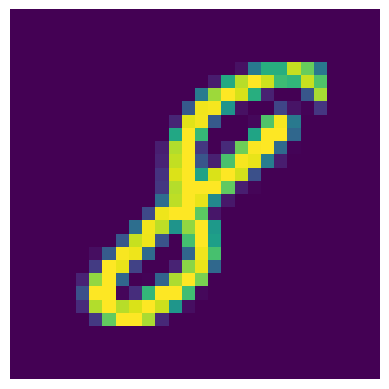

In [4]:
import matplotlib as mpl 
import matplotlib.pyplot as plt
import numpy as np
X, y = mnist["data"].to_numpy(), mnist["target"].to_numpy()
#print(X.shape)
#print(y.shape)
some_digit = X[7777]
some_digit_image = some_digit.reshape(28, 28)
plt.imshow(some_digit_image)
plt.axis("off")
print(y[7777])

In [5]:
#Convert y to a number:
y = y.astype(np.uint8)
#Split into train and test set, MNIST already did, 60000 vs 10000 
x_train = X[:60000]
y_train = y[:60000]

x_test = X[60000:]
y_test = y[60000:]

#Now, we create binary classifier; binary classifier only classes between 2 classes, for example, 8 and not 8:
y_train_8 = (y_train == 8)
y_test_8 = (y_test == 8)

#Use SGD classifier, look it up for our documentation:
from sklearn.linear_model import SGDClassifier

sgd_clf = SGDClassifier(random_state=42)
sgd_clf.fit(x_train, y_train_8)
sgd_clf.predict([some_digit]) 

array([False])

In [6]:
from sklearn.model_selection import cross_val_score
cross_val_score(sgd_clf, x_train, y_train_8, cv=3, scoring="accuracy") #accuracy is not a good metric for this dataset, because it is very imbalanced, 10% of the data is 8s, so if we just classify everything as not 8, we will get 90% accuracy, which is not good. We need to look at other metrics such as precision and recall.

array([0.909  , 0.9286 , 0.88285])

In [7]:
#Now, let's do confusion matrix approach. For a confusion matrix, let's say we want to know how many times 5s is classified as 3s, we look at fifth row, 3rd column
from sklearn.model_selection import cross_val_predict
y_train_pred = cross_val_predict(sgd_clf, x_train, y_train_8, cv=3)#Instead of returning accuracy, it returns predictions made on each test fold
from sklearn.metrics import confusion_matrix
#For confusion matrix, row represents ACTUAL class, columns represents PREDICTED class, so rows in this case are true non-8 and true 8s, columns are predicted non-8 and predicted 8s
confusion_matrix(y_train_8, y_train_pred)
#Result: 50006 true negatives, 4143 false positives. 1448 false negatives, 4403 true positives.
#A perfect binary classifier would have 0 false positives and 0 false negatives 

array([[50006,  4143],
       [ 1448,  4403]], dtype=int64)

In [8]:
#use recall and precision:
from sklearn.metrics import precision_score, recall_score
precision_score(y_train_8, y_train_pred) #Precision is the ratio of true positives to all positive predictions, so it is 4403/(4403+4143) = 0.515; So when it classifies a picture as 8, it is only right 51.5% => Column 2 mean
recall_score(y_train_8, y_train_pred) #Recall is the ratio of true positives to all actual positives, so it is 4403/(4403+1448) = 0.753; so out of all pictures of truly 8s, it only detects 75.3% of them => Row 2 mean
print("Precision:", precision_score(y_train_8, y_train_pred))
print("Recall:", recall_score(y_train_8, y_train_pred))
#Check out the precision-recall tradeoff:

Precision: 0.515211794991809
Recall: 0.7525209365920356


In [9]:
#Also checkout F scores, which is the harmonic mean of precision and recall:
from sklearn.metrics import f1_score
f1_score(y_train_8, y_train_pred) #F1 score is 2* (precision * recall) / (precision + recall) = 0.612, which is not very good, but it is better than random guessing, which would give us an F1 score of 0.5

0.6116552059456831

In [10]:
#Now, move to threshold in binary classification
y_scores = sgd_clf.decision_function([some_digit])
#print(y_scores) #The higher the score, the more confident the classifier is that it is an 8. The default threshold is 0, so if the score is above 0, it will classify it as an 8, otherwise it will classify it as not an 8.
threshold = 0
y_some_digit_pred = (y_scores > threshold)
print(y_some_digit_pred)

[False]


In [11]:
threshold = 8000
y_some_digit_pred = (y_scores > threshold)
print(y_some_digit_pred)#If y_scores is above 8000, then it successfully classifies the image as 8

[False]


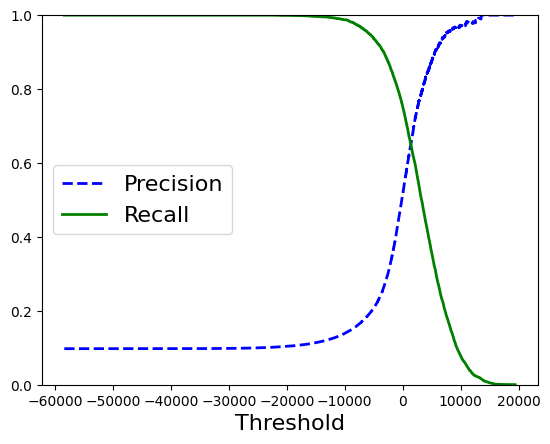

In [12]:
#Now sketch the precision-recall curve:
y_scores = cross_val_predict(sgd_clf, x_train, y_train_8, cv=3, method="decision_function") #Instead of returning predictions, it returns the decision scores for each instance
from sklearn.metrics import precision_recall_curve
precisions, recalls, thresholds = precision_recall_curve(y_train_8, y_scores)

def plot_precision_recall_vs_threshold(precisions, recalls, thresholds):
    plt.plot(thresholds, precisions[:-1], "b--", label="Precision", linewidth=2)
    plt.plot(thresholds, recalls[:-1], "g-", label="Recall", linewidth=2)
    plt.xlabel("Threshold", fontsize=16)
    plt.legend(loc="center left", fontsize=16)
    plt.ylim([0, 1])
plot_precision_recall_vs_threshold(precisions, recalls, thresholds)
plt.show()
#A general idea is as threshold increases, precision increases and recall decreases. So if we want to have a high precision, we need to set a high threshold, but that will decrease our recall. If we want to have a high recall, we need to set a low threshold, but that will decrease our precision. So we need to find a good balance between precision and recall.

In [13]:
#So, if we want a high precision, we just set a high threshold. For example, 90% precision:
#To get threshold, call np.argmax
threshold_90_precision = thresholds[np.argmax(precisions >= 0.90)] #So it is the threshold that gives us 90% precision, which is 3370.0
print("Threshold for 90% precision:", threshold_90_precision)
y_train_pred_90 = (y_scores >= threshold_90_precision)
print("Precision:", precision_score(y_train_8, y_train_pred_90))
print("Recall:", recall_score(y_train_8, y_train_pred_90))

Threshold for 90% precision: 5558.688951079276
Precision: 0.9003419638495359
Recall: 0.3149888907878995


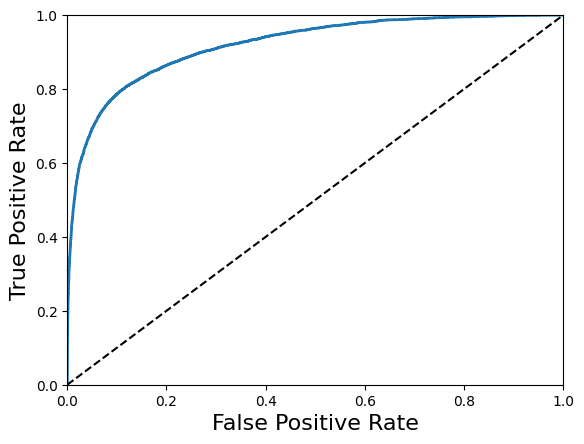

In [14]:
#Now, let's try using ROC - Receiver Operating Characteristic curve; recall sensitivity and specificity in STA3100
from sklearn.metrics import roc_curve
fpr, tpr, thresholds = roc_curve(y_train_8, y_scores) #fpr is false positive rate, tpr is true positive rate, thresholds is the threshold for each point in the curve 
def plot_roc_curve(fpr, tpr, label=None):
    plt.plot(fpr, tpr, linewidth=2, label=label)
    plt.plot([0, 1], [0, 1], 'k--') #plot the diagonal line
    plt.axis([0, 1, 0, 1]) #set the axis limits
    plt.xlabel('False Positive Rate', fontsize=16)
    plt.ylabel('True Positive Rate', fontsize=16)
plot_roc_curve(fpr, tpr)
plt.show()

In [15]:
#To evaluate how good the ROC curve is, we can calculate the area under the curve (AUC): A perfect classifier would have an AUC of 1, while a random classifier would have an AUC of 0.5
from sklearn.metrics import roc_auc_score
roc_auc_score(y_train_8, y_scores)

0.9192599874103056

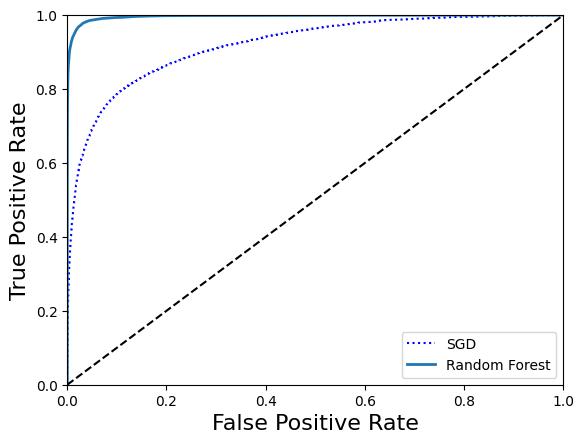

In [16]:
#Now, let's compare using RandomForestClassifier.
#Note that RandomForestClassifier does not have a decision_function method, but it has a predict_proba method that returns an array with rows corresponding to instances and columns corresponding to classes, each containing the probability a given instance belongs to that class
from sklearn.ensemble import RandomForestClassifier

forest_clf = RandomForestClassifier(random_state=42)
y_probas_forest = cross_val_predict(forest_clf, x_train, y_train_8, cv=3, method="predict_proba") #This will return the probability of each instance belonging to each class
y_scores_forest = y_probas_forest[:, 1] #We are interested in the probability of the positive class (class 1), which is the second column
fpr_forest, tpr_forest, thresholds_forest = roc_curve(y_train_8, y_scores_forest) #Now, let's plot the ROC curve for both classifiers

plt.plot(fpr, tpr, "b:", label="SGD")
plot_roc_curve(fpr_forest, tpr_forest, "Random Forest")
plt.legend(loc="lower right")
plt.show()#Random Forest is much better than SGD, it has a much higher true positive rate for the same false positive rate. The AUC score for Random Forest is also much higher than SGD.

In [17]:
#Now, we do multi classifications; for our case classify for 10 digits. We have 2 choices:
#1. One-versus-all (OvA): for each class, train a binary classifier to separate that class from the rest. So we will have 10 binary classifiers, one for each class.
#2. One-versus-one (OvO): for each pair of classes, train a binary classifier to separate those two classes. For N classes, we will have N*(N-1)/2 classifiers 
#Some algorithms is bad at scaling, so they prefer OvO; however, for most binary classifiers, OvR is preferred. 

#let's try SVM, which prefers OvO: 

from sklearn.svm import SVC
svm_clf = SVC()
svm_clf.fit(x_train, y_train)
svm_clf.predict([some_digit])

array([8], dtype=uint8)

In [18]:
#It got the right answer, but let's examine the actual scores:
some_digit_scores = svm_clf.decision_function([some_digit])
print(some_digit_scores) #It gives us 10 scores, the highest is for class 8; however, it has some doubt for class 3 also

[[ 2.72432774  6.26245656  5.12040924  8.26203195  0.7195912   7.26674398
   3.76976282 -0.30739661  9.3133848   1.74082707]]


In [19]:
#Let's scale the data a little bit:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train.astype(np.float64))
#Now it is much better than before, it is above 97% accuracy; however, it is still not good enough for production use, we need to do more hyperparameter tuning and try other algorithms.

In [20]:
#cross_val_score(sgd_clf, x_train_scaled, y_train, cv=3, scoring="accuracy") 

In [24]:
#Let's visualize our confunsion matrix for the multi-class classification:
#It run too slow => Look at the book for confusion matrix; basically the diagonal is the number of correct classifications for each class => This number should be higher than other entries
#If plot into a square, this diagonal will be the brightest
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import cross_val_predict
y_train_pred = cross_val_predict(sgd_clf, x_train_scaled, y_train, cv=2) #Should have used x_train_scaled but our computer loads too slow:
confx_mx = confusion_matrix(y_train, y_train_pred)
confx_mx 

c:\Users\Minh Son Tran\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_stochastic_gradient.py:733: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
c:\Users\Minh Son Tran\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_stochastic_gradient.py:733: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(


array([[5601,    0,   27,    7,   11,   55,   39,    6,  175,    2],
       [   0, 6426,   45,   22,    4,   47,    4,   11,  172,   11],
       [  32,   32, 5283,   91,   67,   25,   73,   46,  297,   12],
       [  29,   24,  124, 5244,    2,  222,   26,   46,  329,   85],
       [  15,   14,   52,   12, 5250,   11,   39,   25,  256,  168],
       [  32,   17,   32,  174,   50, 4494,   78,   24,  443,   77],
       [  28,   20,   47,    2,   49,   92, 5561,    6,  112,    1],
       [  17,   12,   59,   28,   54,   10,    6, 5727,  124,  228],
       [  19,   66,   57,   84,    4,  119,   32,   10, 5395,   65],
       [  22,   17,   36,   64,  138,   28,    1,  185,  278, 5180]],
      dtype=int64)

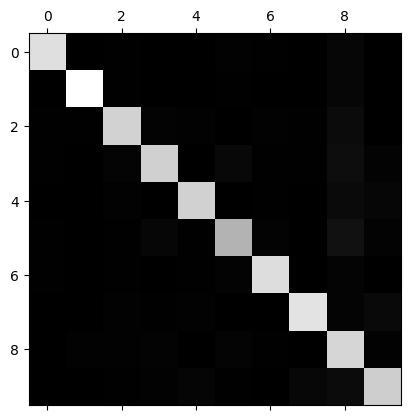

In [ ]:
#Let's visualize this confusion matrix in a square:
plt.matshow(confx_mx, cmap=plt.cm.gray)
plt.show()
#looks good, note that at 5 it is slightly dark

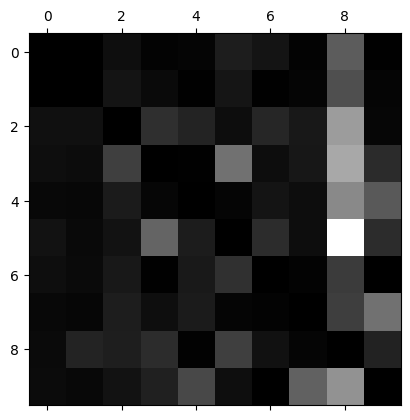

In [ ]:
#Now, investigate even more. Try looking at errors ratio:
row_sums = confx_mx.sum(axis=1, keepdims=True) 
norm_confx_mx = confx_mx / row_sums

np.fill_diagonal(norm_confx_mx, 0) #Fill the diagonal with zeros to keep only the errors, so we can visualize the errors more clearly
plt.matshow(norm_confx_mx, cmap=plt.cm.gray)
plt.show()
#See that lots of numbers get misclassified as 8s; but 8s are not that bad in getting misclassified as other numbers. 
#The book states that 3 and 5 looks kind of mixed together, so let's investigate this:

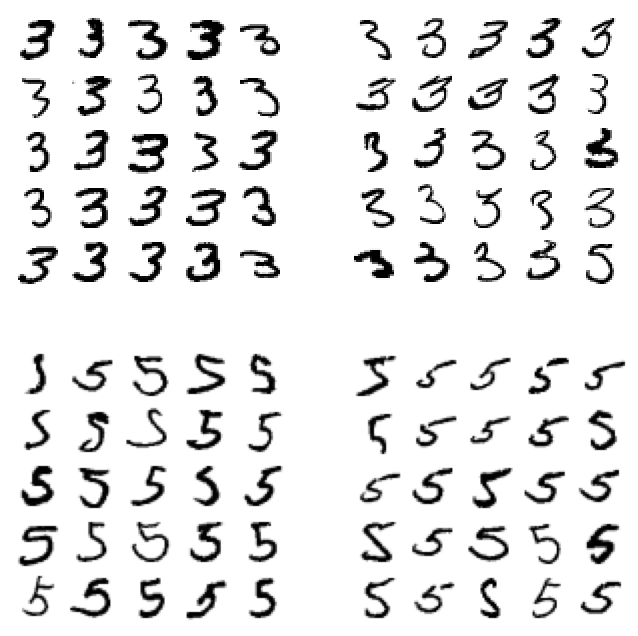

In [ ]:
def plot_digits(instances, images_per_row=5, **options):
    size = 28
    images_per_row = min(len(instances), images_per_row)
    n_rows = (len(instances) - 1) // images_per_row + 1

    row_images = []
    n_empty = n_rows * images_per_row - len(instances)
    instances = np.concatenate([instances, np.zeros((n_empty, size * size))], axis=0)

    for row in range(n_rows):
        rimages = instances[row * images_per_row: (row + 1) * images_per_row]
        row_images.append(np.concatenate(rimages.reshape(images_per_row, size, size), axis=1))
    
    image = np.concatenate(row_images, axis=0)
    plt.imshow(image, cmap="binary", **options)
    plt.axis("off")
class_3 =3
class_5 = 5
X_class3_class3 = x_train[(y_train == class_3) & (y_train_pred == class_3)]
X_class3_class5 = x_train[(y_train == class_3) & (y_train_pred == class_5)]

X_class5_class3 = x_train[(y_train == class_5) & (y_train_pred == class_3)]
X_class5_class5 = x_train[(y_train == class_5) & (y_train_pred == class_5)]

plt.figure(figsize=(8, 8))
plt.subplot(221); plot_digits(X_class3_class3[:25], images_per_row=5)
plt.subplot(222); plot_digits(X_class3_class5[:25], images_per_row=5)

plt.subplot(223); plot_digits(X_class5_class3[:25], images_per_row=5)
plt.subplot(224); plot_digits(X_class5_class5[:25], images_per_row=5)

#Top Right and bottom left are the one that got confused